# 06 - Feature Analysis: Demographics Variables

## Purpose
This notebook performs comprehensive feature analysis on the demographics variables (ACS + engineered features) to identify:
1. **Redundant features** - highly correlated pairs (|r| > 0.85)
2. **Multicollinearity** - VIF values indicating collinear variables
3. **Predictive relevance** - correlation with target variable (CRD Mortality Rate)
4. **Feature groupings** - hierarchical clustering patterns

## Goal
Make informed decisions about which features to keep/drop before modeling:
- **Drop** one variable from highly correlated pairs
- **Keep** variables with strongest predictive signal for CRD Mortality Rate

## Input
- `data/combined_final/final_combined_all_variables.csv` (from notebook 05)

## Output
- Analysis plots saved to `data/outputs/feature_analysis/`
- Drop decisions carried forward to notebook 08

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

pandas: 2.3.3
numpy: 1.26.4


## 2. Setup Output Directory

In [2]:
output_dir = Path('../data/outputs/feature_analysis')
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory ready: {output_dir}")

Output directory ready: ../data/outputs/feature_analysis


## 3. Load Data

In [3]:
df = pd.read_csv('../data/combined_final/final_combined_all_variables.csv')

print("=" * 70)
print("DATASET LOADED")
print("=" * 70)
print(f"Shape: {df.shape}")
print(f"  - Rows: {df.shape[0]:,}")
print(f"  - Columns: {df.shape[1]}")
print(f"  - Years: {sorted(df['Year'].unique())}")

DATASET LOADED
Shape: (24487, 131)
  - Rows: 24,487
  - Columns: 131
  - Years: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]


## 4. Identify Demographics Variables

In [4]:
demographics_cols = [
    'Median Household Income',
    'Total Population',
    'Gini Index',
    'Median Age',
    'Poverty Rate',
    'Unemployment Rate',
    'Disability Rate',
    "Bachelor's Degree or Higher (%)",
    "High School Degree or Higher (%)",
    'White Population (%)',
    'Hispanic Population (%)',
    'Black Population (%)',
    'Households with No Vehicle (%)',
    'Rent Burden (+50% of HI)',
    'Single Mother Families (%)'
]

demographics_cols = [col for col in demographics_cols if col in df.columns]
demographics_df = df[demographics_cols + ['CRD Mortality Rate']].copy()

print(f"Demographics variables identified: {len(demographics_cols)}")
for i, col in enumerate(demographics_cols, 1):
    print(f"  {i:2}. {col}")

Demographics variables identified: 15
   1. Median Household Income
   2. Total Population
   3. Gini Index
   4. Median Age
   5. Poverty Rate
   6. Unemployment Rate
   7. Disability Rate
   8. Bachelor's Degree or Higher (%)
   9. High School Degree or Higher (%)
  10. White Population (%)
  11. Hispanic Population (%)
  12. Black Population (%)
  13. Households with No Vehicle (%)
  14. Rent Burden (+50% of HI)
  15. Single Mother Families (%)


## 5. Descriptive Statistics

In [5]:
print("=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)

missing = demographics_df.isnull().sum()
if missing.sum() > 0:
    print("\nMissing values detected:")
    for col in missing[missing > 0].index:
        print(f"  {col}: {missing[col]:,}")
else:
    print("\nNo missing values")

print("\nSummary statistics:")
demographics_df.describe()

DESCRIPTIVE STATISTICS

No missing values

Summary statistics:


,Median Household Income,Total Population,Gini Index,Median Age,Poverty Rate,Unemployment Rate,Disability Rate,Bachelor's Degree or Higher (%),High School Degree or Higher (%),White Population (%),Hispanic Population (%),Black Population (%),Households with No Vehicle (%),Rent Burden (+50% of HI),Single Mother Families (%),CRD Mortality Rate
count,24487.000000,2.448700e+04,24487.000000,24487.000000,24487.000000,24487.000000,24487.000000,24487.000000,24487.000000,24487.000000,24487.000000,24487.000000,24487.000000,24487.000000,24487.000000,24487.000000
mean,48233.304651,1.026567e+05,0.442419,40.916838,16.261861,7.336080,15.754952,20.333132,85.025659,83.777410,8.850831,9.159245,6.335325,18.749546,9.333859,0.000753
std,12781.930179,3.268580e+05,0.034952,5.192459,6.467213,3.554617,4.393675,9.295640,7.034022,16.170373,13.539941,14.603102,3.600459,6.295253,3.569848,0.000195
min,18972.000000,6.120000e+02,0.320900,21.900000,2.300000,0.000000,3.700000,2.800000,45.200000,8.327612,0.000000,0.000000,0.000000,0.000000,0.000000,0.000181
25%,39884.500000,1.161500e+04,0.418400,37.800000,11.600000,4.900000,12.600000,13.900000,80.800000,77.444854,1.902210,0.629889,4.353163,14.689051,6.990433,0.000612
50%,46443.000000,2.652800e+04,0.440100,40.900000,15.400000,6.900000,15.300000,18.100000,86.500000,90.125538,3.724928,2.280021,5.781473,18.861210,8.876812,0.000737
75%,54041.500000,6.877650e+04,0.463900,44.000000,19.800000,9.300000,18.400000,24.300000,90.300000,95.425543,8.972632,10.492625,7.593302,22.869515,11.127111,0.000872
max,142299.000000,1.010572e+07,0.707000,67.400000,55.500000,29.900000,36.900000,75.300000,98.700000,100.000000,99.184800,87.412281,78.304029,50.156703,30.714648,0.001873


## 6. Inter-Feature Correlation Analysis

### 6.1 Correlation Matrix Heatmap

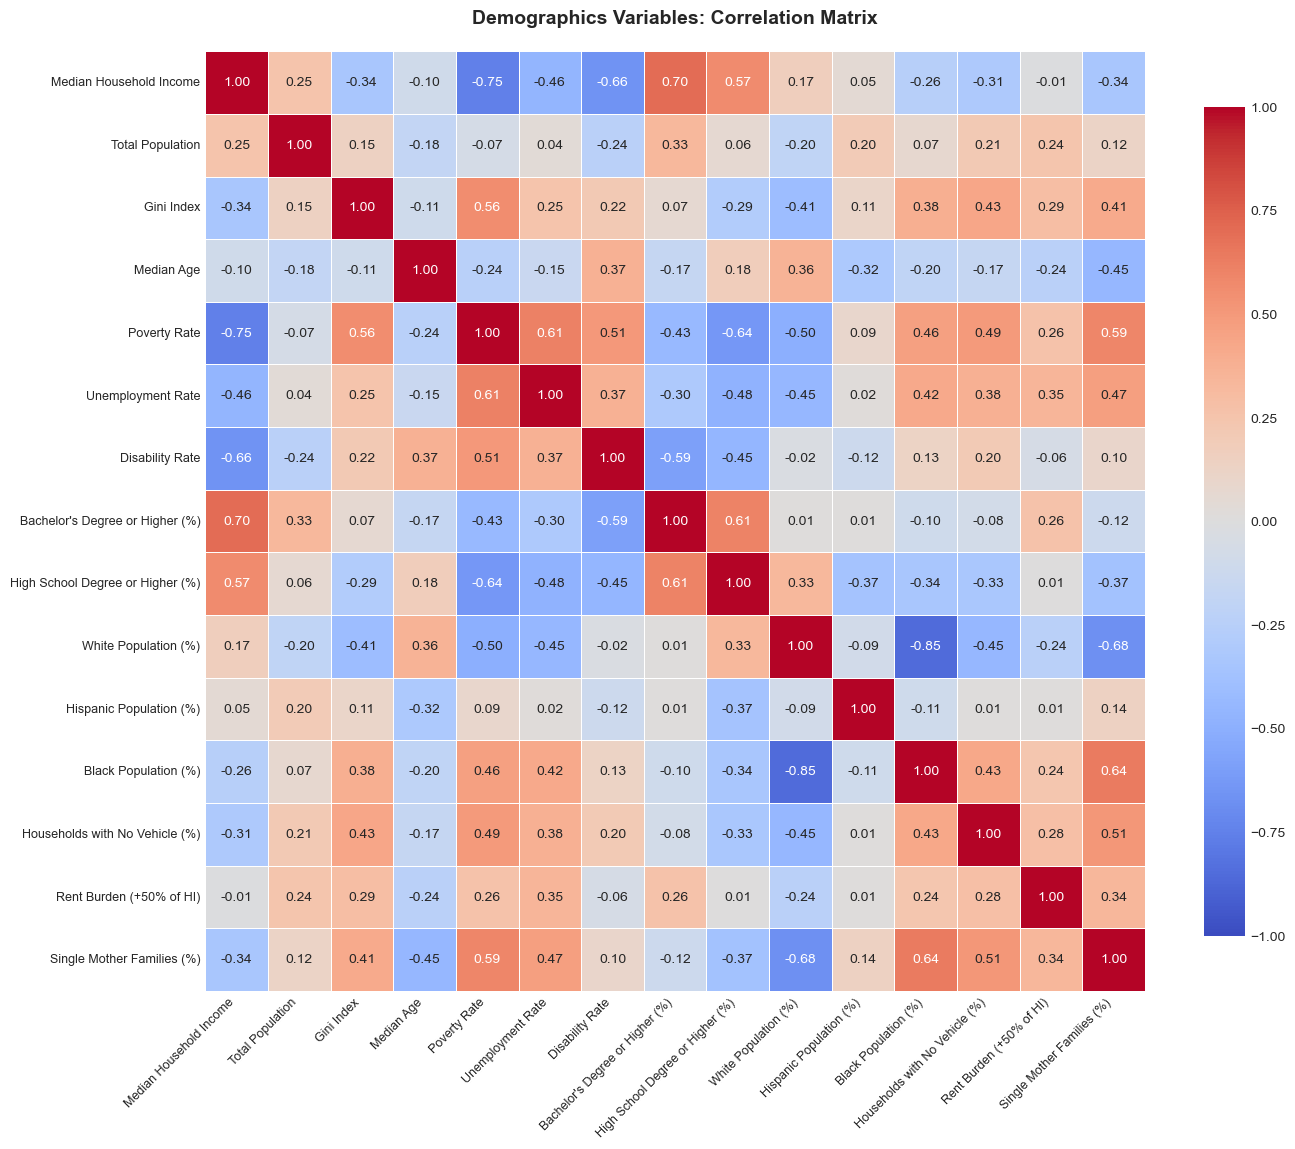

Saved: demographics_correlation_heatmap.png


In [6]:
corr_matrix = demographics_df[demographics_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8},
            ax=ax)
ax.set_title('Demographics Variables: Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(output_dir / 'demographics_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: demographics_correlation_heatmap.png")

### 6.2 High Correlation Pairs (|r| > 0.85)

In [7]:
print("=" * 70)
print("HIGH CORRELATION PAIRS (|r| > 0.85)")
print("=" * 70)

threshold = 0.85
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append({
                'Variable 1': corr_matrix.columns[i],
                'Variable 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
    print(f"\nFound {len(high_corr_pairs)} high-correlation pairs:")
    print(high_corr_df.to_string(index=False))
else:
    print("\nNo pairs with |r| > 0.85 found")

HIGH CORRELATION PAIRS (|r| > 0.85)

Found 1 high-correlation pairs:
          Variable 1           Variable 2  Correlation
White Population (%) Black Population (%)    -0.852227


### 6.3 Hierarchical Clustering Dendrogram

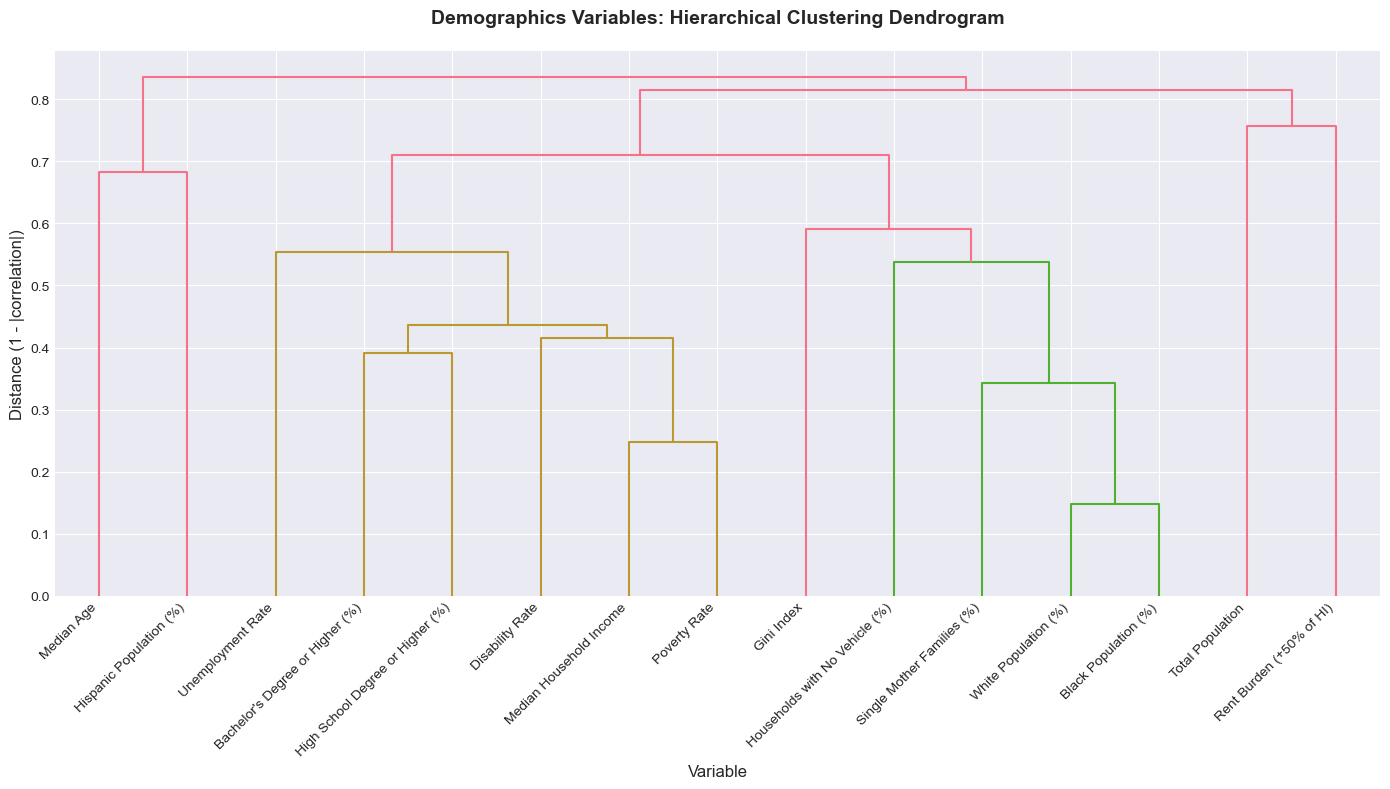

Saved: demographics_dendrogram.png


In [8]:
distance_matrix = 1 - np.abs(corr_matrix)
linkage_matrix = linkage(squareform(distance_matrix), method='average')

fig, ax = plt.subplots(figsize=(14, 8))
dendrogram(linkage_matrix,
           labels=corr_matrix.columns,
           orientation='top',
           distance_sort='ascending',
           show_leaf_counts=False,
           leaf_font_size=10,
           ax=ax)
ax.set_title('Demographics Variables: Hierarchical Clustering Dendrogram',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Variable', fontsize=12)
ax.set_ylabel('Distance (1 - |correlation|)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(output_dir / 'demographics_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: demographics_dendrogram.png")

## 7. Relationship with Target Variable

### 7.1 Feature-Target Correlation

FEATURE CORRELATION WITH TARGET (CRD Mortality Rate)

Ranked by absolute correlation:

Disability Rate                     0.565349
Bachelor's Degree or Higher (%)    -0.540932
Median Household Income            -0.509110
Poverty Rate                        0.437792
High School Degree or Higher (%)   -0.412639
Unemployment Rate                   0.274176
Total Population                   -0.230293
Single Mother Families (%)          0.188903
Hispanic Population (%)            -0.180161
Gini Index                          0.093418
Black Population (%)                0.086795
Households with No Vehicle (%)      0.083286
Median Age                         -0.075957
Rent Burden (+50% of HI)           -0.073214
White Population (%)               -0.001999


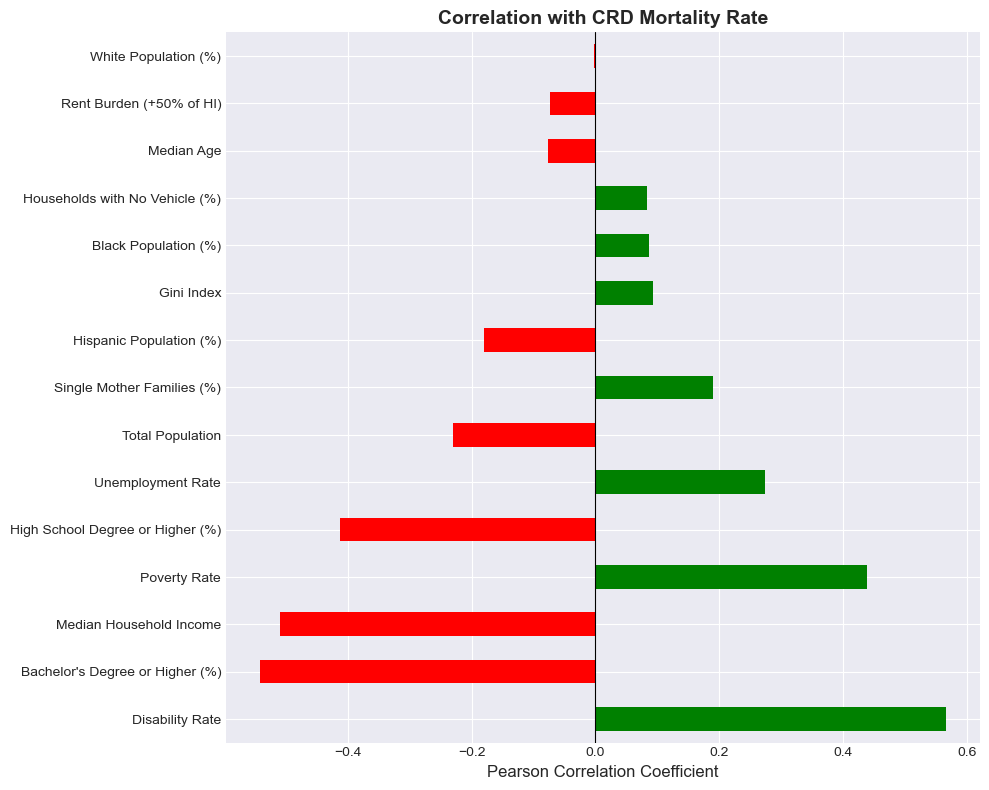

Saved: demographics_target_correlation.png


In [9]:
target_corr = demographics_df[demographics_cols].corrwith(demographics_df['CRD Mortality Rate'])
target_corr = target_corr.sort_values(key=abs, ascending=False)

print("=" * 70)
print("FEATURE CORRELATION WITH TARGET (CRD Mortality Rate)")
print("=" * 70)
print("\nRanked by absolute correlation:")
print("\n" + target_corr.to_string())

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['green' if x > 0 else 'red' for x in target_corr.values]
target_corr.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Correlation with CRD Mortality Rate', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient', fontsize=12)
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig(output_dir / 'demographics_target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: demographics_target_correlation.png")

### 7.2 Bivariate Scatter Plots (Top 6 Features)

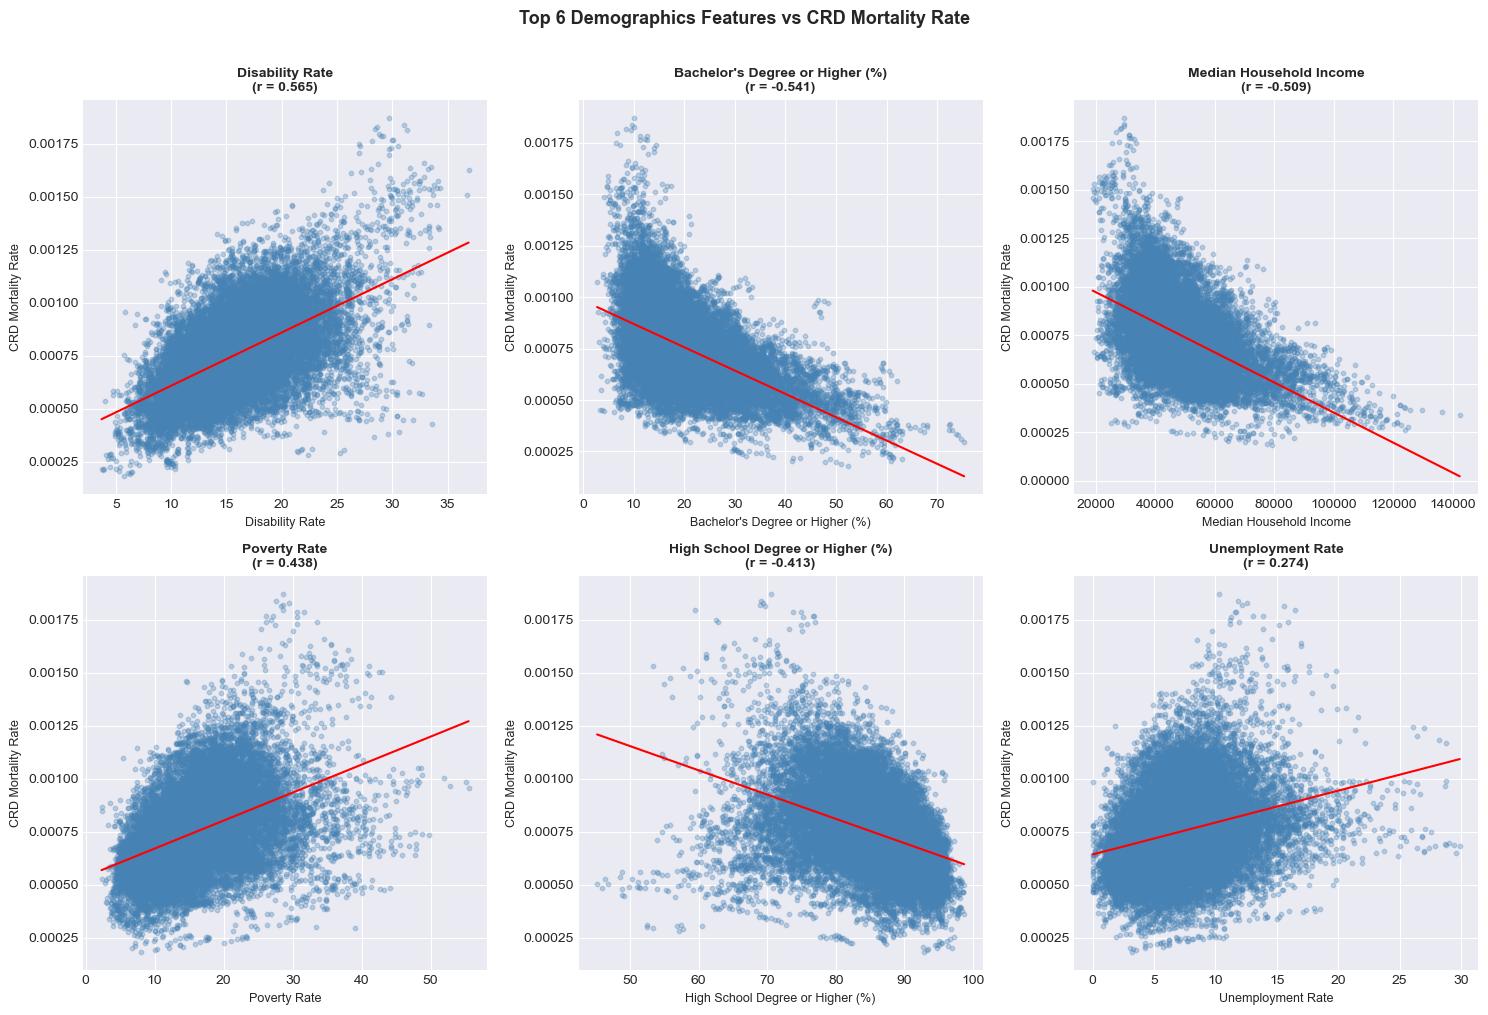

Saved: demographics_scatter_top6.png


In [10]:
top_features = target_corr.abs().nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    ax = axes[idx]
    ax.scatter(demographics_df[feature],
               demographics_df['CRD Mortality Rate'],
               alpha=0.3, s=10, color='steelblue')
    z = np.polyfit(demographics_df[feature].dropna(),
                   demographics_df.loc[demographics_df[feature].notna(), 'CRD Mortality Rate'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(demographics_df[feature].min(), demographics_df[feature].max(), 100)
    ax.plot(x_line, p(x_line), 'r-', linewidth=1.5)
    r = target_corr[feature]
    ax.set_title(f'{feature}\n(r = {r:.3f})', fontsize=10, fontweight='bold')
    ax.set_xlabel(feature, fontsize=9)
    ax.set_ylabel('CRD Mortality Rate', fontsize=9)

plt.suptitle('Top 6 Demographics Features vs CRD Mortality Rate', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(output_dir / 'demographics_scatter_top6.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: demographics_scatter_top6.png")

## 8. Multicollinearity Detection (VIF)

- VIF < 5: Low multicollinearity
- VIF 5-10: Moderate multicollinearity
- VIF > 10: High multicollinearity (problematic)

In [11]:
vif_data = demographics_df[demographics_cols].dropna()

print("=" * 70)
print("VARIANCE INFLATION FACTOR (VIF) ANALYSIS")
print("=" * 70)

vif_results = []
for i, col in enumerate(demographics_cols):
    try:
        vif_value = variance_inflation_factor(vif_data.values, i)
        vif_results.append({'Variable': col, 'VIF': vif_value})
        print(f"  {col}: VIF = {vif_value:.2f}")
    except Exception as e:
        print(f"  {col}: Could not compute VIF ({e})")

vif_df = pd.DataFrame(vif_results).sort_values('VIF', ascending=False)
print("\nVIF Summary (sorted):")
print(vif_df.to_string(index=False))

VARIANCE INFLATION FACTOR (VIF) ANALYSIS
  Median Household Income: VIF = 53.26
  Total Population: VIF = 1.48
  Gini Index: VIF = 272.13
  Median Age: VIF = 129.40
  Poverty Rate: VIF = 38.20
  Unemployment Rate: VIF = 10.12
  Disability Rate: VIF = 36.01
  Bachelor's Degree or Higher (%): VIF = 17.56
  High School Degree or Higher (%): VIF = 278.78
  White Population (%): VIF = 115.41
  Hispanic Population (%): VIF = 2.15
  Black Population (%): VIF = 5.98
  Households with No Vehicle (%): VIF = 6.79
  Rent Burden (+50% of HI): VIF = 15.21
  Single Mother Families (%): VIF = 21.89

VIF Summary (sorted):
                        Variable        VIF
High School Degree or Higher (%) 278.780860
                      Gini Index 272.130601
                      Median Age 129.400590
            White Population (%) 115.409539
         Median Household Income  53.259543
                    Poverty Rate  38.203266
                 Disability Rate  36.006847
      Single Mother Families (%)  2

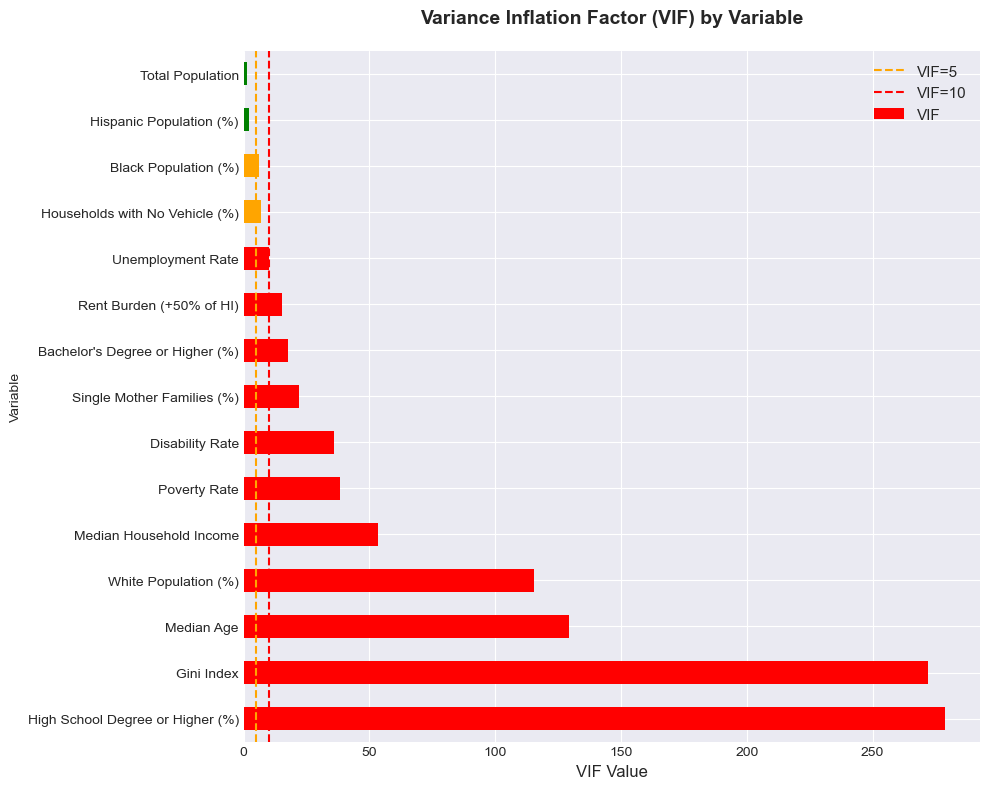

Saved: demographics_vif.png


In [12]:
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['green' if x < 5 else 'orange' if x < 10 else 'red'
          for x in vif_df['VIF'].values]
vif_df.set_index('Variable')['VIF'].plot(kind='barh', color=colors, ax=ax)
ax.set_title('Variance Inflation Factor (VIF) by Variable', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('VIF Value', fontsize=12)
ax.axvline(x=5, color='orange', linestyle='--', linewidth=1.5, label='VIF=5')
ax.axvline(x=10, color='red', linestyle='--', linewidth=1.5, label='VIF=10')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(output_dir / 'demographics_vif.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: demographics_vif.png")

## 9. Drop Decision

Based on the analysis above, identify which demographics variables to drop due to high inter-feature correlation or low predictive relevance. These decisions are carried forward to notebook 08.

In [13]:
demographics_to_drop = [
    'Rent Burden (+50% of HI)',
    'Median Household Income',
    'Gini Index',
    'High School Degree or Higher (%)',
    'Median Age'
]

demographics_to_keep = [col for col in demographics_cols if col not in demographics_to_drop]

print("=" * 70)
print("DROP DECISIONS: DEMOGRAPHICS VARIABLES")
print("=" * 70)
print(f"\nVariables to DROP ({len(demographics_to_drop)}):")
for col in demographics_to_drop:
    print(f"  - {col}")

print(f"\nVariables to KEEP ({len(demographics_to_keep)}):")
for col in demographics_to_keep:
    r = target_corr.get(col, float('nan'))
    print(f"  - {col}  (r with CRD Mortality Rate = {r:.3f})")

DROP DECISIONS: DEMOGRAPHICS VARIABLES

Variables to DROP (5):
  - Rent Burden (+50% of HI)
  - Median Household Income
  - Gini Index
  - High School Degree or Higher (%)
  - Median Age

Variables to KEEP (10):
  - Total Population  (r with CRD Mortality Rate = -0.230)
  - Poverty Rate  (r with CRD Mortality Rate = 0.438)
  - Unemployment Rate  (r with CRD Mortality Rate = 0.274)
  - Disability Rate  (r with CRD Mortality Rate = 0.565)
  - Bachelor's Degree or Higher (%)  (r with CRD Mortality Rate = -0.541)
  - White Population (%)  (r with CRD Mortality Rate = -0.002)
  - Hispanic Population (%)  (r with CRD Mortality Rate = -0.180)
  - Black Population (%)  (r with CRD Mortality Rate = 0.087)
  - Households with No Vehicle (%)  (r with CRD Mortality Rate = 0.083)
  - Single Mother Families (%)  (r with CRD Mortality Rate = 0.189)
